# Reporte 01: Discretización Espacial y Asignación de Impedancia Temporal (VFT)

## 01.- Marco Teórico
En el analisis de las redes de transporte Urbano, la topología estática no refleja la realidad operativa. Para resolver esto, el presente modelo inyecta atributos dinámicos a cada vector de la red ($\vec{uv}$) utilizando la **Ecuación VFT**.  
El tiempo de traslado continuo ($T_t$) de un segmento geodésico se discretiza matemáticamente mediante la siguiente expresión:

$$T_t = \left( \frac{D}{V} \right) \times C_f$$

Donde:
* **$D$**: Distancia esférica del segmento en metros (calculada vía Haversine).
* **$V$**: Velocidad comercial imputada en m/min.
* **$C_f$**: Coeficiente de Fricción Vial. Calculado en función del nivel de permeabilidad del derecho de vía (e.g., mixto, confinado, exclusivo) y ponderado por un factor de saturación característico de la CDMX.

Adicionalmente, el modelo aísla la "paradoja de la espera fantasma" segregando el Costo de Abordaje ($T_b$), el cual será evaluado exclusivamente en los nodos de transferencia intermodal:

$$T_b = \frac{F}{2}$$

*(Donde $F$ es la frecuencia de paso de los vehículos en minutos).*

In [3]:
# Habilitar recarga automática para reflejar cambios en 'src' sin reiniciar el notebook
%load_ext autoreload
%autoreload 2

import sys
import os

proyecto_path = os.path.abspath('..')
if proyecto_path not in sys.path:
    sys.path.append(proyecto_path)

print(f"Ruta del proyecto cargada: {proyecto_path}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Ruta del proyecto cargada: /home/galigaribaldi/Documentos/Code/VFTModel


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
## Modulos propios
from src.api.schemas.schemas import GeoJSONTransportSchema
from src.infrastructure.go_client.client import fetch_full_network
from src.core.services.graph_builder import build_and_plot_network

raw_data = await fetch_full_network()

validated_payload = GeoJSONTransportSchema(**raw_data)

# 3. Construcción topológica y cálculo de Impedancia VFT
grafo_vft = build_and_plot_network(validated_payload)

print(f"\nResumen de la Red Analizada:")
print(f"Nodos (Estaciones/Vértices): {grafo_vft.number_of_nodes()}")
print(f"Aristas (Vectores de flujo): {grafo_vft.number_of_edges()}")

2026-04-05 20:49:43 | INFO     | VFT_Model | Construyendo el puente hacia el módulo espacial de Go...
2026-04-05 20:49:43 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonEstacion
2026-04-05 20:49:43 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonLinea
2026-04-05 20:49:44 | INFO     | VFT_Model | Red extraída: 22785 entidades espaciales listas para VFT.
2026-04-05 20:49:44 | INFO     | VFT_Model | Iniciando la construcción del Grafo VFT...
2026-04-05 20:49:44 | INFO     | VFT_Model | Grafo Dirigido construido: 101621 Nodos topológicos y 93816 Segmentos de flujo.
2026-04-05 20:49:44 | INFO     | VFT_Model | Llamando al Motor de Impedancia VFT...
2026-04-05 20:49:44 | INFO     | VFT_Model | Iniciando inyección de motor de impendancia sobre VFT:
2026-04-05 20:49:45 | INFO     | VFT_Model | Impedancia aplicada exitosamente a 93816 segmentos.

Resumen de la Red Analizada:
Nodos (Estaciones/

## 2. Análisis Estadístico de la Impedancia Inyectada
A continuación, extraemos los atributos multidimensionales calculados en el modelo `VFTImpedanceModel` para validar su coherencia física frente a los distintos sistemas de transporte.

In [7]:
# Extraer las propiedades de todas las aristas
edges_data = []
for u, v, data in grafo_vft.edges(data=True):
    # Filtrar solo aristas que tengan atributos calculados (ignorar transferencias peatonales por ahora)
    if 'travel_time_min' in data:
        edges_data.append({
            'Origen_Lon': u[0],
            'Origen_Lat': u[1],
            'Sistema': data.get('sistema', 'Desconocido'),
            'Derecho_Via': data.get('derecho_de_via', 'mixto'),
            'Distancia_m': data.get('distancia_segmento_m', 0),
            'Friccion_Cf': data.get('coeficiente_friccion', 1.0),
            'Tiempo_Viaje_min': data.get('travel_time_min', 0.0),
            'Costo_Abordaje_min': data.get('boarding_cost_min', 0.0)
        })

df_edges = pd.DataFrame(edges_data)

# Mostrar las primeras filas del conjunto analítico
df_edges.head()

,Origen_Lon,Origen_Lat,Sistema,Derecho_Via,Distancia_m,Friccion_Cf,Tiempo_Viaje_min,Costo_Abordaje_min
0,-99.087875,19.565483,SistemaTransporte.mexicable,exclusivo,71.22,1.0,0.2374,0.25
1,-99.093294,19.540998,SistemaTransporte.mexicable,exclusivo,24.69,1.0,0.0741,1.00
2,-99.078141,19.553460,SistemaTransporte.mexicable,exclusivo,118.54,1.0,0.3951,0.25
3,-99.074490,19.549124,SistemaTransporte.mexicable,exclusivo,193.93,1.0,0.6464,0.25
4,-99.118265,19.498247,SistemaTransporte.mexicable,exclusivo,19.56,1.0,0.0587,1.00


## 3. Glosario de Indicadores Analíticos (Modelo VFT)

Para facilitar la interpretación de los resultados estadísticos obtenidos de la red, a continuación se definen métricas clave evaluadas por el algoritmo de impedancia:

* **Segmentos_Analizados:** Representa el número total de vectores o "calles" físicas que componen la topología del sistema. No es la longitud total de la ruta, sino en cuántos fragmentos de esquina a esquina cortó el modelo a la ciudad.
* **Distancia_Promedio_m:** La longitud media (en metros) de cada segmento topológico. Calculada de nodo a nodo mediante geometría esférica (Fórmula de Haversine).
* **Friccion_Promedio ($C_f$):** El nivel de castigo temporal que sufre el transporte por interactuar con la ciudad. Un valor de `1.0` indica flujo ininterrumpido (ej. un túnel del Metro), mientras que valores cercanos a `1.8` indican un fuerte embotellamiento por tráfico mixto.
* **Tiempo_Promedio_min:** El tiempo neto estimado en minutos que le toma al vehículo cruzar un segmento promedio. Es el resultado dinámico de procesar la distancia, la velocidad comercial y la fricción vial ($C_f$).

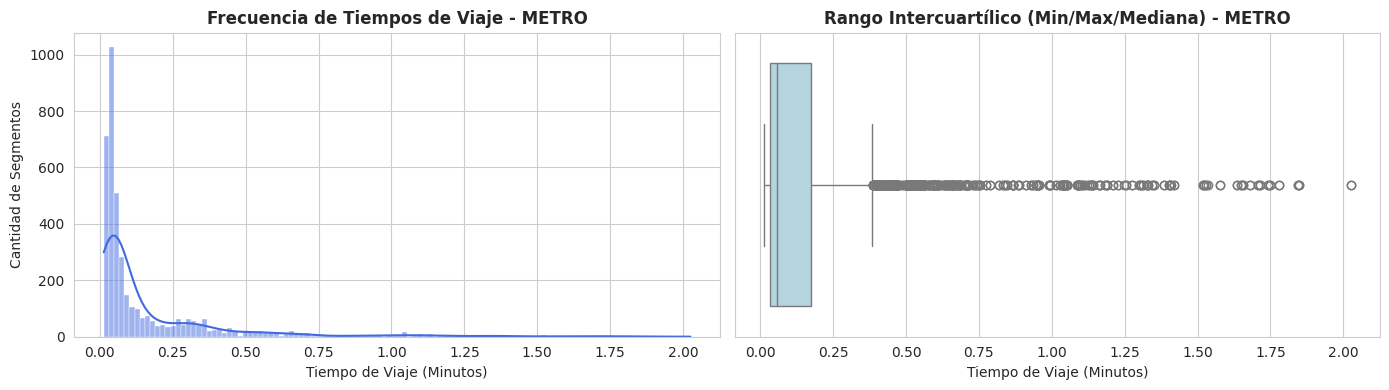

### Resumen de Impedancia y Estadísticas: **METRO**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,95.98,8.12,18.76,31.34,98.71,2051.11
Friccion_Cf,1.00,1.00,1.00,1.00,1.00,1.00
Tiempo_Viaje_min,0.18,0.01,0.03,0.06,0.18,3.31


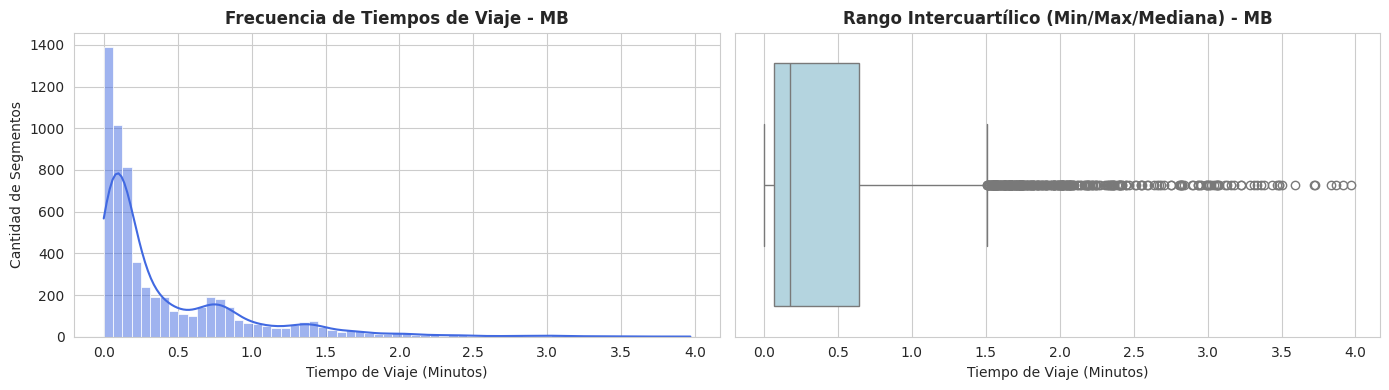

### Resumen de Impedancia y Estadísticas: **MB**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,117.94,0.0,18.72,53.43,171.41,2812.89
Friccion_Cf,1.00,1.0,1.00,1.00,1.00,1.00
Tiempo_Viaje_min,0.44,0.0,0.07,0.18,0.65,9.32


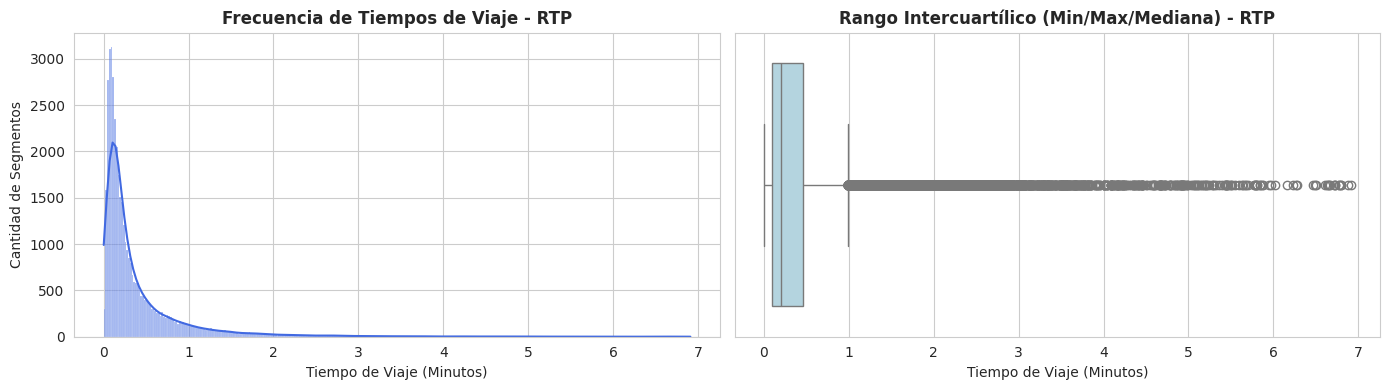

### Resumen de Impedancia y Estadísticas: **RTP**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,62.44,0.11,14.7,29.05,67.32,2758.52
Friccion_Cf,1.40,1.40,1.4,1.40,1.40,1.40
Tiempo_Viaje_min,0.42,0.00,0.1,0.20,0.46,18.87


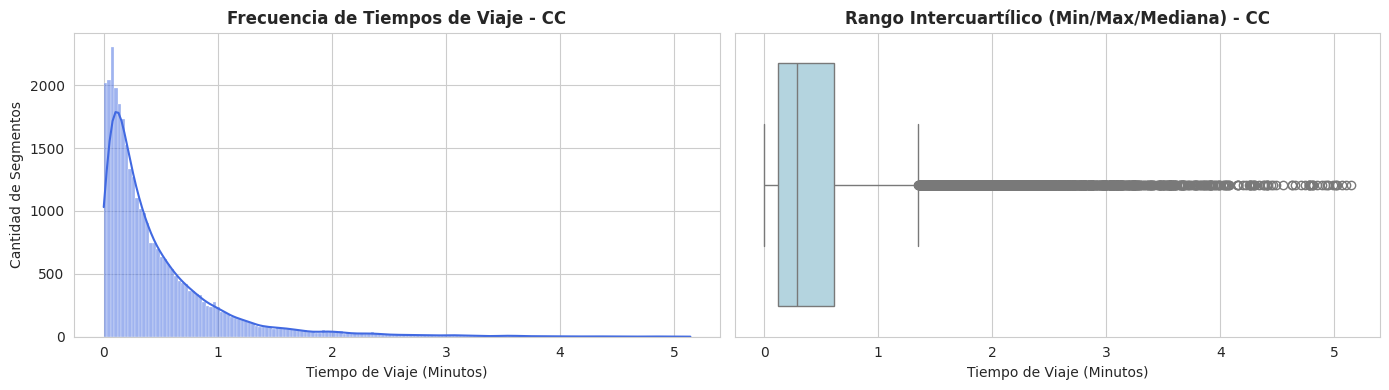

### Resumen de Impedancia y Estadísticas: **CC**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,94.10,0.01,23.61,55.93,120.00,2046.55
Friccion_Cf,1.40,1.40,1.40,1.40,1.40,1.40
Tiempo_Viaje_min,0.48,0.00,0.12,0.29,0.62,9.92


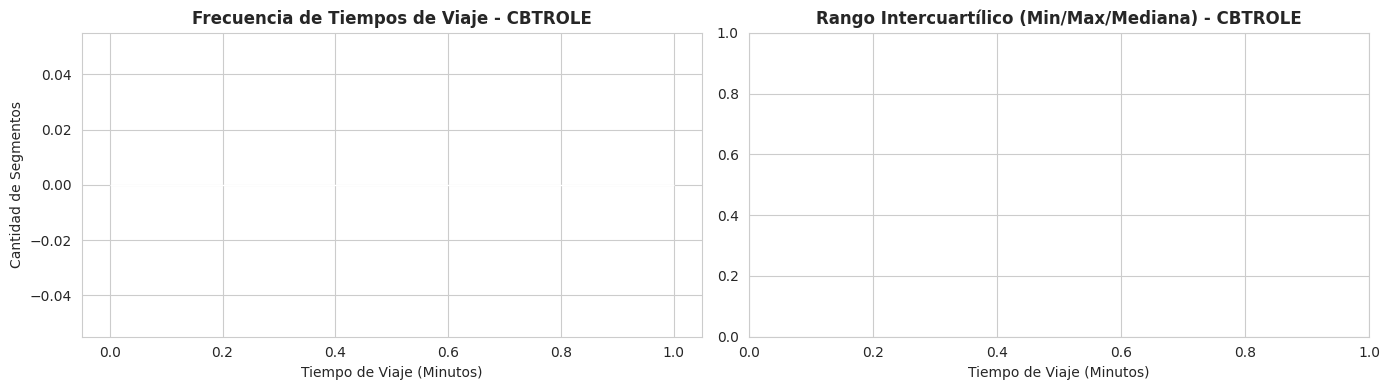

### Resumen de Impedancia y Estadísticas: **CBTROLE**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,NaN,NaN,NaN,NaN,NaN,NaN
Friccion_Cf,NaN,NaN,NaN,NaN,NaN,NaN
Tiempo_Viaje_min,NaN,NaN,NaN,NaN,NaN,NaN


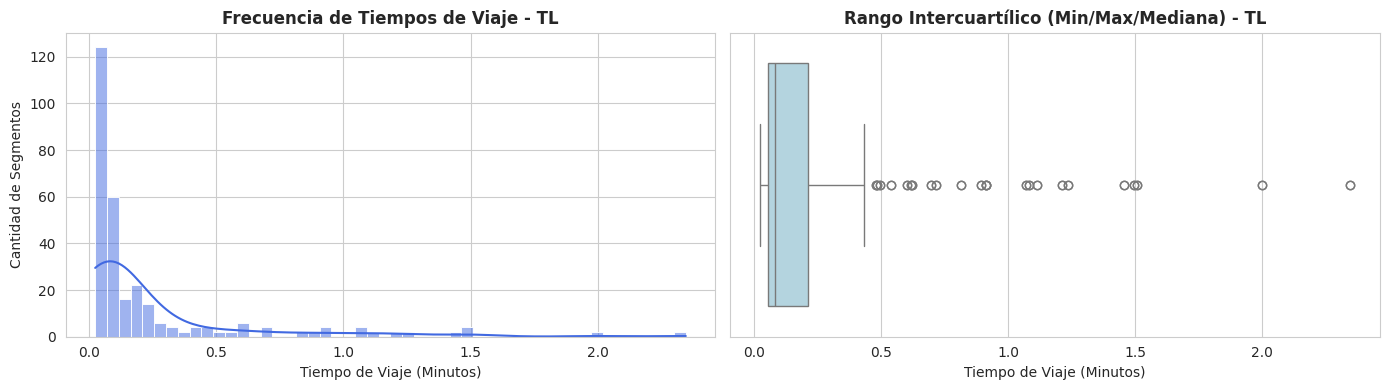

### Resumen de Impedancia y Estadísticas: **TL**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,84.35,8.50,19.01,28.69,73.11,807.07
Friccion_Cf,1.00,1.00,1.00,1.00,1.00,1.00
Tiempo_Viaje_min,0.25,0.02,0.06,0.08,0.21,2.35


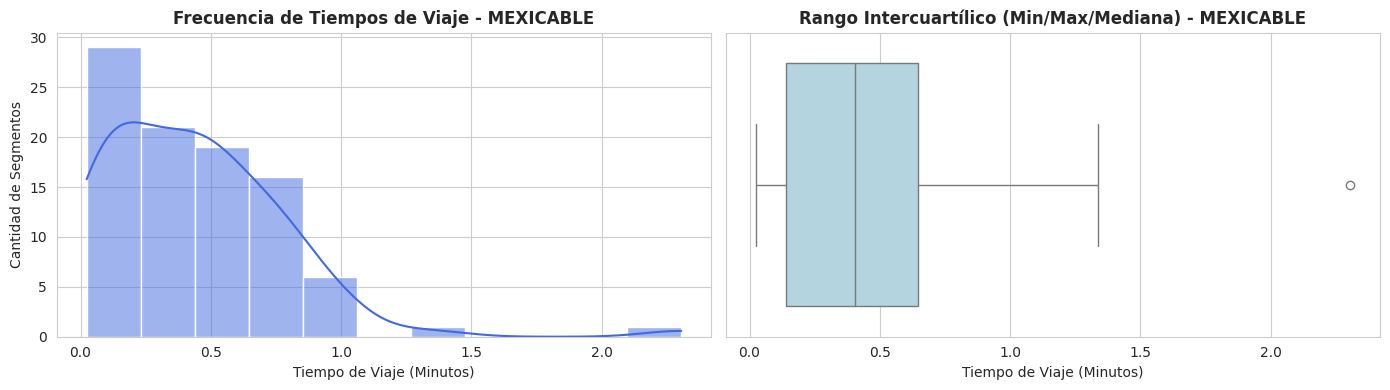

### Resumen de Impedancia y Estadísticas: **MEXICABLE**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,140.79,7.05,46.98,131.61,210.66,691.47
Friccion_Cf,1.00,1.00,1.00,1.00,1.00,1.00
Tiempo_Viaje_min,0.44,0.02,0.14,0.40,0.65,2.30


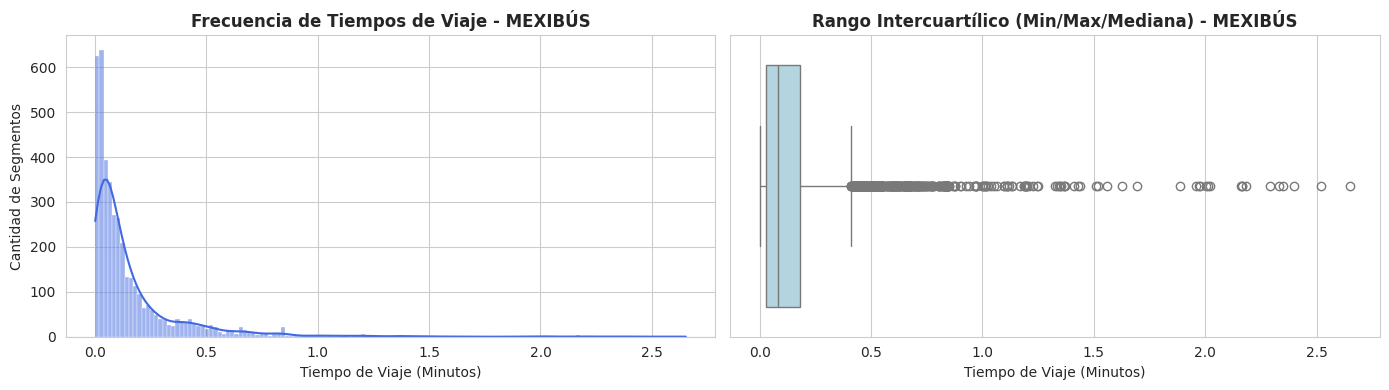

### Resumen de Impedancia y Estadísticas: **MEXIBÚS**

,Promedio,Mínimo,Cuartil 25%,Mediana (50%),Cuartil 75%,Máximo
Distancia_m,58.34,0.22,10.89,29.09,65.60,952.74
Friccion_Cf,1.16,1.16,1.16,1.16,1.16,1.16
Tiempo_Viaje_min,0.16,0.00,0.03,0.08,0.18,2.65


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Configuración visual global para las gráficas
sns.set_style("whitegrid")

# 1. Separar el DF masivo en DataFrames individuales por sistema
sistemas_principales = ['METRO', 'MB', 'RTP', 'CC', 'CB'
                        'TROLE', 'TL', 'MEXICABLE', 'MEXIBÚS']

# Creamos un diccionario para acceder a ellos fácilmente
dfs_por_sistema = {}
for sistema in sistemas_principales:
    dfs_por_sistema[sistema] = df_edges[df_edges['Sistema'] == sistema].copy()

# 2. Análisis iterativo por sistema: Gráficas y Percentiles
for sistema in sistemas_principales:
    df_sis = dfs_por_sistema[sistema]
    
    # Filtro opcional: Limitamos a segmentos < 1000m solo para que la gráfica no se deforme 
    # por valores atípicos (ej. un cablebús de 3km sin paradas). La tabla sí usa todos los datos.
    df_sis_plot = df_sis[df_sis['Distancia_m'] < 1000] 
    
    # Crear figura con dos paneles: Histograma de Tiempos y Boxplot de Cuartiles
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Panel Izquierdo: Curva de Distribución (Cómo se agrupan los tiempos)
    sns.histplot(data=df_sis_plot, x='Tiempo_Viaje_min', kde=True, color='royalblue', ax=axes[0])
    axes[0].set_title(f'Frecuencia de Tiempos de Viaje - {sistema}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Tiempo de Viaje (Minutos)')
    axes[0].set_ylabel('Cantidad de Segmentos')
    
    # Panel Derecho: Boxplot (Muestra Mínimo, Máximo y Cuartiles)
    sns.boxplot(data=df_sis_plot, x='Tiempo_Viaje_min', color='lightblue', ax=axes[1])
    axes[1].set_title(f'Rango Intercuartílico (Min/Max/Mediana) - {sistema}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Tiempo de Viaje (Minutos)')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Generar la Tabla Estadística Descriptiva (Promedio, Max, Min, Percentiles)
    # Pandas .describe() ya calcula los percentiles 25%, 50% (mediana) y 75%
    stats = df_sis[['Distancia_m', 'Friccion_Cf', 'Tiempo_Viaje_min']].describe().T
    
    # Filtramos y renombramos las columnas para que sean claras y académicas
    stats = stats[['mean', 'min', '25%', '50%', '75%', 'max']] 
    stats.columns = ['Promedio', 'Mínimo', 'Cuartil 25%', 'Mediana (50%)', 'Cuartil 75%', 'Máximo']
    
    # Mostrar el título y la tabla renderizada
    display(Markdown(f"### Resumen de Impedancia y Estadísticas: **{sistema}**"))
    display(stats.round(2)) # Redondeamos a 2 decimales para limpieza
    print("=" * 100) # Línea divisoria entre sistemas

---
### 4. Nota Aclaratoria y Limitaciones del Modelo Base

Los resultados expuestos en esta fase de la investigación representan el **desplazamiento teórico ideal** de la red. Para una correcta interpretación metodológica, se establecen las siguientes delimitaciones:

1. **Naturaleza de las Distancias:** Las longitudes segmentales ($D$) son aproximaciones geodésicas (calculadas mediante la fórmula de Haversine) basadas en el mapeo topológico de la red de transporte. Representan la distancia espacial entre nodos, no necesariamente el trazo milimétrico de las curvas de las calles.
2. **Tiempos Nominales:** El tiempo de viaje actual asume condiciones operativas constantes. Representa la capacidad estructural del sistema antes de ser sometido a perturbaciones estocásticas en tiempo real (condiciones dinámicas que se abordarán en fases posteriores).
3. **Fundamento de la Fricción Vial:** Los ponderadores utilizados para el cálculo del Coeficiente de Fricción Vial ($C_f$) se fundamentan en los lineamientos de diseño urbano e interacción modal establecidos en el **Manual de Calles: Diseño Vial para Ciudades Mexicanas (2019)**. 
   * *Fuente Oficial:* [SEDATU / Gobierno de la CDMX (PDF)](https://www.gob.mx/cms/uploads/attachment/file/509173/Manual_de_calles_2019.pdf)